In [1]:
# import statements
import pandas as pd
import requests
import json

import matplotlib.pyplot as plt


## Data Handling + Split

In [67]:
#call data and clean (remove null and duplicate values)
df_old = pd.read_csv('C:/Users/minju/Desktop/DS3000-26Summer/Farmers-Market/datasets/agriculture_dataset.csv')
df_old=df_old.drop_duplicates()

missing_codes = ["--", "", " ", "nan", "NaN", "None"] #account for different possible null combos


for col in df_old.columns:
    if df_old[col].dtype == object:  # only clean string/object columns
        df_old[col] = df_old[col].str.strip().replace(missing_codes, pd.NA)
    else:
        df_old[col] = df_old[col].replace(missing_codes, pd.NA) 

df_old = df_old.dropna()  # remove rows with any null values

print(df_old.columns)
df_old.head()


Index(['High_Resolution_RGB', 'Multispectral_Images', 'Thermal_Images',
       'Temporal_Images', 'Spatial_Resolution', 'GPS_Coordinates',
       'Field_Boundaries', 'Elevation_Data', 'Canopy_Coverage', 'NDVI', 'SAVI',
       'Chlorophyll_Content', 'Leaf_Area_Index', 'Crop_Stress_Indicator',
       'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Soil_Moisture',
       'Soil_pH', 'Organic_Matter', 'Pest_Hotspots', 'Weed_Coverage',
       'Pest_Damage', 'Crop_Growth_Stage', 'Expected_Yield', 'Crop_Type',
       'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Water_Flow',
       'Drainage_Features', 'Crop_Health_Label'],
      dtype='object')


,High_Resolution_RGB,Multispectral_Images,Thermal_Images,Temporal_Images,Spatial_Resolution,GPS_Coordinates,Field_Boundaries,Elevation_Data,Canopy_Coverage,NDVI,...,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Expected_Yield,Crop_Type,Ground_Truth_Segmentation,Bounding_Boxes,Water_Flow,Drainage_Features,Crop_Health_Label
0,0,0,0,0,0.667324,201538,3,28.207634,8.046926,0.676945,...,1.922274,84,2,2540.784327,Wheat,1,5,41.771884,0,1
1,1,1,0,0,1.459000,215854,3,82.335147,147.512332,0.414781,...,4.851381,56,3,3227.617025,Wheat,0,1,27.564635,0,1
2,0,0,0,0,0.500442,890802,3,83.865629,30.246527,0.723610,...,5.974859,38,1,4609.938146,Maize,1,8,29.510836,0,1
3,0,0,0,0,1.865161,605584,3,20.747905,6.857820,0.405611,...,2.100598,27,2,1409.716754,Maize,0,1,34.822855,0,0
4,0,1,1,1,1.392331,871732,3,22.588815,26.168558,0.465992,...,3.025669,84,4,3905.312588,Rice,0,2,15.493255,1,0


In [68]:
import numpy as np

#Randomly remove percent of elements of data to improve efficiency
percentRemove=0.5
num_rows_rem=int(len(df_old)*percentRemove)

rows_remove=np.random.choice(df_old.index, num_rows_rem, replace=False)
df = df_old.drop(rows_remove)

del df_old

df.head()

,High_Resolution_RGB,Multispectral_Images,Thermal_Images,Temporal_Images,Spatial_Resolution,GPS_Coordinates,Field_Boundaries,Elevation_Data,Canopy_Coverage,NDVI,...,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Expected_Yield,Crop_Type,Ground_Truth_Segmentation,Bounding_Boxes,Water_Flow,Drainage_Features,Crop_Health_Label
1,1,1,0,0,1.459000,215854,3,82.335147,147.512332,0.414781,...,4.851381,56,3,3227.617025,Wheat,0,1,27.564635,0,1
2,0,0,0,0,0.500442,890802,3,83.865629,30.246527,0.723610,...,5.974859,38,1,4609.938146,Maize,1,8,29.510836,0,1
5,0,0,0,0,2.342274,251493,3,46.683234,29.525247,0.507520,...,4.426726,1,1,3186.428122,Wheat,0,6,41.304044,0,0
6,0,0,0,0,1.745272,665471,3,20.582658,22.422320,0.499019,...,0.892302,58,1,3096.231256,Wheat,0,9,3.313661,1,0
8,0,0,1,0,0.862034,300672,3,23.027399,3.294899,0.500893,...,1.884896,21,3,2492.937443,Wheat,1,4,18.688151,0,1


### undersample majority for better log regression model

In [99]:
# Check current class distribution
print("Before balancing:")
print(df['Crop_Health_Label'].value_counts())

# Separate by class
df_class_1 = df[df['Crop_Health_Label'] == 1]
df_class_0 = df[df['Crop_Health_Label'] == 0]

# Randomly sample 1s to match the number of 0s
df_class_1_downsampled = df_class_1.sample(n=len(df_class_0), random_state=42)

# Recombine and shuffle
df_balanced = pd.concat([df_class_0, df_class_1_downsampled])
df= df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing:")
print(df['Crop_Health_Label'].value_counts())

Before balancing:
Crop_Health_Label
1    31929
0    31929
Name: count, dtype: int64

After balancing:
Crop_Health_Label
1    31929
0    31929
Name: count, dtype: int64


In [100]:
#one-hot encoding to turn categorical value into numerical
#create df_sub and df_sub_drop (clean dataset/create subsets)
df_sub = df.drop(columns='Crop_Health_Label', axis=1)
df_sub = pd.get_dummies(df_sub, columns=['Crop_Type','Crop_Growth_Stage'], dtype=int)

columnsToDrop = ['High_Resolution_RGB','Multispectral_Images', 'Thermal_Images',
       'Temporal_Images','Field_Boundaries', 'Pest_Hotspots',
       'Crop_Type_Maize','Crop_Type_Rice','Crop_Type_Wheat', 
       'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Drainage_Features','Crop_Growth_Stage_1','Crop_Growth_Stage_2','Crop_Growth_Stage_3','Crop_Growth_Stage_4']
df_sub_drop = df_sub.drop(columns=columnsToDrop, axis=1)

df_sub_drop.head()
#df_sub.head()


,Spatial_Resolution,GPS_Coordinates,Elevation_Data,Canopy_Coverage,NDVI,SAVI,Chlorophyll_Content,Leaf_Area_Index,Crop_Stress_Indicator,Temperature,Humidity,Rainfall,Wind_Speed,Soil_Moisture,Soil_pH,Organic_Matter,Weed_Coverage,Pest_Damage,Expected_Yield,Water_Flow
0,0.538035,808281,64.413995,64.194438,0.547115,0.570069,1.147562,2.806118,64,29.701412,56.035952,8.503881,0.931687,28.285460,6.403818,0.733199,4.136928,89,2568.315989,24.255860
1,1.755023,541713,30.750212,17.906934,0.639469,0.426104,1.671598,3.963854,98,26.946248,70.879580,26.332095,1.031382,32.590688,6.510339,0.858044,3.751972,83,1777.121982,18.679425
2,0.599176,957562,96.707455,31.141839,0.583213,0.324657,1.210792,1.654674,56,16.867076,41.958770,29.050657,0.815692,20.619950,7.273736,3.980621,1.843259,24,3161.810687,41.099331
3,0.297091,829983,29.220176,44.422635,0.358472,0.413041,0.746718,0.597806,69,28.633208,39.162137,14.024046,0.554288,15.852205,6.525694,0.997760,0.689847,75,3856.328274,5.406434
4,1.500508,686832,82.009263,78.852966,0.310286,0.468568,3.197536,3.531508,22,24.249466,36.337990,2.016255,1.598326,18.792752,6.430675,0.422066,1.184235,39,2657.232046,46.344980


In [101]:
#binary columns to add back
binary_cols = df_sub[['Pest_Hotspots','Crop_Growth_Stage_1','Crop_Growth_Stage_2','Crop_Growth_Stage_3','Crop_Growth_Stage_4',
       'Crop_Type_Maize','Crop_Type_Rice','Crop_Type_Wheat', 
       'Ground_Truth_Segmentation', 'Drainage_Features']].to_numpy()


In [102]:
df_sub_drop.shape

(63858, 20)

In [103]:
from sklearn.model_selection import train_test_split
#split continuous and binary data at same time, consistent rand state
y_vec = df['Crop_Health_Label'].to_numpy()

X_train_cont, X_test_cont, y_train, y_test = train_test_split(
    df_sub_drop.to_numpy(), y_vec, test_size=0.2, random_state=3000
)
binary_train, binary_test, _, _ = train_test_split(
    binary_cols, y_vec, test_size=0.2, random_state=3000
)

In [104]:
import numpy as np
from sklearn.preprocessing import StandardScaler

#scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cont)
X_test_scaled = scaler.transform(X_test_cont)

#add binary columns back
X_train = np.concatenate([X_train_scaled, binary_train], axis=1)
X_test = np.concatenate([X_test_scaled, binary_test], axis=1)

#add column of y-intercept. ONLY FOR LOG REG!
ones = np.ones((X_train.shape[0], 1), dtype=X_train.dtype)
X_train_reg = np.hstack([ones, X_train])

ones = np.ones((X_test.shape[0], 1), dtype=X_test.dtype)
X_test_reg = np.hstack([ones, X_test])

#pd.DataFrame(X_train_scaled).head()
#pd.DataFrame(X_test_scaled).head()

pd.DataFrame(X_test_reg).head()



,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,1.0,0.972879,0.585350,1.374949,0.363870,-0.300079,-0.496677,1.331034,-0.887000,0.751699,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,-0.109306,0.195248,-0.923970,-0.675507,1.701089,-0.542295,-0.317311,0.525735,1.237276,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1.0,0.001381,-0.351839,-0.710234,-0.653954,-0.253855,2.342846,2.448541,-1.075277,1.445381,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,-0.305035,0.637756,0.167107,-0.840749,0.149365,0.749531,0.703346,-1.308522,1.341328,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.409887,-1.283038,-0.397694,0.474299,1.457301,0.175092,-0.488634,-0.877502,1.584117,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


## KNN Model

In [106]:
def knn_cos_with_loop(X_train, y_train, X_test, k):

    y_pred = []
    nearest_neighbors = []

    train_norms = np.linalg.norm(X_train, axis=1, keepdims=True)
    
    X_train_norm = X_train / train_norms
    #i = 0
    for testp in X_test:
        #i += 1
        #print(f'The current iteration is: {i}', end='\r')

        norm_test = testp/np.linalg.norm(testp)
        similarities = norm_test @ X_train_norm.T
        #print(similarities.shape)
            
        neighbor_indices = np.argsort(similarities)[-k:]
        del similarities
        #print(neighbor_indices)
        neighbor_values = y_train[neighbor_indices]
        #print(neighbor_values)

        y_pred.append(np.mean(neighbor_values))
        nearest_neighbors.append(neighbor_indices)
    
    return np.array(y_pred), nearest_neighbors

In [107]:
X_train.shape

(51086, 30)

## plot data with ks and model

We are beginning the modeling of k=1
We are beginning the modeling of k=2
We are beginning the modeling of k=3
We are beginning the modeling of k=4
We are beginning the modeling of k=5


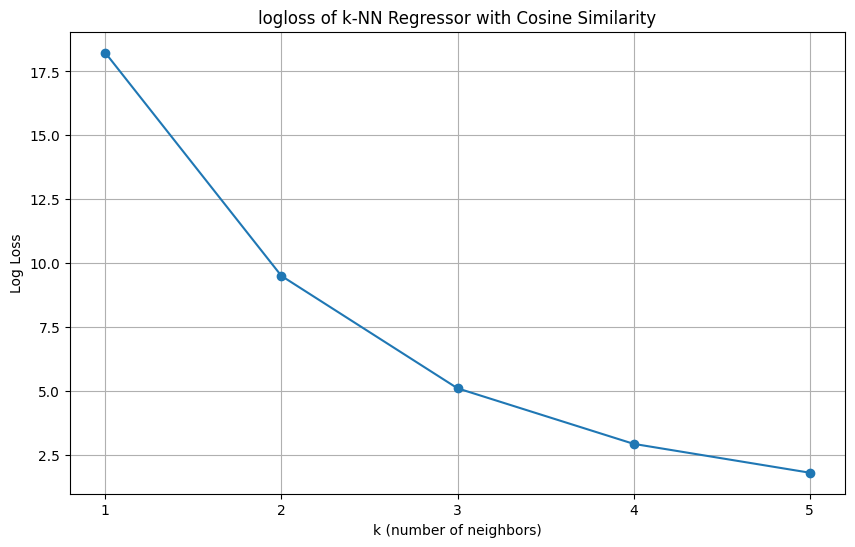

In [108]:
# loop through different values of k, keeping track of MSE for the test set predictions
# first with cosine similarity
from sklearn.metrics import log_loss

k_values = [1, 2, 3, 4, 5]
logloss_values = []
for k in k_values:
    print(f'We are beginning the modeling of k={k}')
    y_pred, _ = knn_cos_with_loop(X_train, y_train, X_test, k)
    #logloss = np.mean(-y_test*np.log(y_pred) - (1-y_test)*np.log(1-y_pred))
    
    logloss = log_loss(y_test, y_pred)
    logloss_values.append(logloss)

# plot the logloss values for different k
plt.figure(figsize=(10, 6))
plt.plot(k_values, logloss_values, marker='o')
plt.title('logloss of k-NN Regressor with Cosine Similarity')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Log Loss')
plt.xticks(k_values)
plt.grid()

## Logistic Regression Model

In [82]:
import numpy as np

In [109]:
#faster logres function
def logistic_regression_loop(X, y, w, alpha=1.0, max_iter=1000):
    """
    A function that runs logistic regression for some maximum number of iterations

    Args:
        X (array): an array of all the predictors where the rows are the observations (includes bias term)
        y (array): an array of all response values (-1 or 1)
        w (array): the initial weight vector
        alpha (float): learning rate (default = 1.0)
        max_iter (int): maximum number of iterations over the dataset (default = 1000)

    Returns:
        w (array): the final weight vector
    """
    w = np.asarray(w, dtype=float).copy() #cast to float to fix dtype error
    n = len(y)

    for _ in range(max_iter): #just run max iter times
        for i in range(n):
            yhat = 1.0 / (1.0 + np.exp(-X[i] @ w))
            w -= alpha * (yhat - y[i]) * X[i]

    print(f"Algorithm reached max_iter={max_iter}, final w = {w}")
    return w

In [20]:
#X_train_reg, X_test_reg
#print(pd.DataFrame(X_train_reg)).columns

In [110]:
X_train_reg.shape

(51086, 31)

In [ ]:
#number of features is 28 +1 (intercept)
weight= np.zeros(X_train_reg.shape[1]) #start from 0s

print(weight)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [112]:
modelRun=logistic_regression_loop(X_train_reg,y_train,weight, alpha = .01)

Algorithm reached max_iter=1000, final w = [-0.80486757  0.03925742 -0.02215289  0.01944338 -0.04471531  0.08586262
  0.00483073  0.04409599 -0.00316924  0.00107893  0.04169841  0.04195231
  0.01498741 -0.02556986  0.02902317 -0.09504796  0.12995617  0.02416466
  0.0048075  -0.03556847  0.01922563 -0.01162999  0.44425214  0.55356597
  0.64932847  0.54798583  0.46769605  0.41338572  0.31405066 -0.0861111
 -0.0568215 ]


In [124]:
def predict_logistic(x, w, pred0 = True):
    '''
    This computes the logistic (sigmoid) function, which maps any real number to a probability between 0 and 1.

    x (array): feature vector x (input by user)
    w (array): weights from model

    pred0: pred0=True predicts the probability of class 1. pred0=False gives the complement, closer to 0
    
    returns yhat: 1D array of predicted probabilities, one per observation

    '''
    if pred0 == True:
        yhat = 1/(1 + np.exp(np.dot(x, w)))
    else:
        yhat = np.exp(np.dot(x, w))/(1 + np.exp(np.dot(x, w)))
    return yhat

yhati = np.apply_along_axis(predict_logistic, 1, X_test_reg, pred0 = False, w=modelRun)

print(yhati.round(3)) #predicted probabilities
print(y_test) #actual labels

[0.613 0.414 0.586 ... 0.524 0.512 0.507]
[0 0 0 ... 0 1 1]


In [125]:
from collections import Counter

Counter(y_test)

Counter({np.int64(1): 6394, np.int64(0): 6378})

In [126]:
yhat_thresh = yhati.round(0)

Counter(yhat_thresh)

Counter({np.float64(1.0): 7783, np.float64(0.0): 4989})

In [127]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, yhat_thresh)
cm

array([[2429, 3949],
       [2560, 3834]])

In [128]:
# True Negative Rate (Correctly predicted Unhealthy Crops)
print(f'True Negative Rate is: {cm[0,0]/sum(cm[0,:])}')
# False Positive Rage
print(f'False Positive Rate is: {1-cm[0,0]/sum(cm[0,:])}')
# True Positive Rate/Rate (correctly predicted Healthy Crops)
print(f'True Positive Rate is: {cm[1,1]/sum(cm[1,:])}')
# False Negaive Rate
print(f'False Negative Rate is: {1-cm[1,1]/sum(cm[1,:])}')
# Precision
print(f'The Precision is: {cm[1,1]/(cm[0,0] + cm[1,1])}')
# F1-Score
precision = cm[1,1]/(cm[0,0] + cm[1,1])
recall = cm[1,1]/sum(cm[1,:])
print(f'The F1-Score is: {2*(precision*recall)/(precision + recall)}')
print(f'The accuracy of the model is: {(cm[0,0] + cm[1,1])/len(y_test)}')

True Negative Rate is: 0.3808403888366259
False Positive Rate is: 0.6191596111633741
True Positive Rate is: 0.5996246481076009
False Negative Rate is: 0.40037535189239915
The Precision is: 0.6121666932779818
The F1-Score is: 0.6058307655842615
The accuracy of the model is: 0.49036955840901975


iter 1-before cut to 50/50: (after one hot encode, got reduce from 70s to 69%)
- True Negative Rate is: 0.009793081661664824
- False Positive Rate is: 0.9902069183383352
- True Positive Rate is: 0.9920650931342883
- False Negative Rate is: 0.007934906865711744
- The Precision is: 0.9958150523118461
- The F1-Score is: 0.9939365357407531
- The accuracy of the model is: 0.6987548344495802

In [63]:
np.mean((y_test - yhat_thresh) ** 2)

np.float64(0.29525516460711254)

## Log Loss Comparison of both models

In [113]:
# log loss for logistic regression
#np.mean(-y_test*np.log(yhati) - (1-y_test)*np.log(1-yhati))
logloss = log_loss(y_test, yhati)

ValueError: Found input variables with inconsistent numbers of samples: [21202, 12772]